# Ecommerce Customers dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
%matplotlib inline

## 1. Load the dataset into a DataFrame

In [2]:
df = pd.read_csv(r'C:\Users\hoofi\Downloads\Ecommerce Customers')

## 2. Explore the data (head, info, describe)

In [3]:
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [5]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


## 3. Perform basic data cleaning if needed

In [6]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (500, 8)

Missing values per column:


,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
missing_count,0,0,0,0,0,0,0,0



Duplicate rows: 0


*There are no null values and no duplicate rows in any of the features*

## 4. Apply feature engineering (if applicable)

### Leakage Features

In [7]:
drop_cols = ['Email', 'Address', 'Avatar']
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)

## 5. Prepare the data for modeling

In [8]:
x = df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = df['Yearly Amount Spent']

## 6. Train a model (use the same model used in the lab)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=101)

In [10]:
lm = LinearRegression()
lm.fit(X_train,y_train)

LinearRegression()

## 7. Evaluate the model performance

### Coefficients Interpretation

In [11]:
print(lm.intercept_)

-1045.115216824574


In [12]:
coeff_df = pd.DataFrame(lm.coef_,x.columns,columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Session Length,25.691540
Time on App,37.892600
Time on Website,0.560581
Length of Membership,61.648594


- Holding all other features fixed, a 1 unit increase in **Avg. Session Length** is associated with an **increase of 25.691540**.
- Holding all other features fixed, a 1 unit increase in **Time on App** is associated with an **increase of 37.892600**.
- Holding all other features fixed, a 1 unit increase in **Time on Website** is associated with an **increase of 0.560581**.
- Holding all other features fixed, a 1 unit increase in **Length of Membership** is associated with an **increase of 61.648594**.

### Predictions

In [13]:
predictions = lm.predict(X_test)

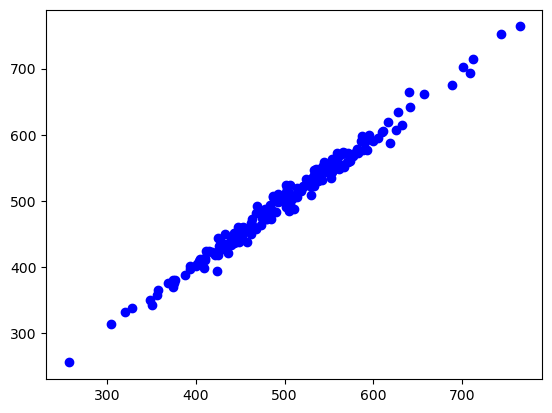

In [24]:
plt.scatter(y_test,predictions,color = 'b')
plt.show()

### Residual Histogram

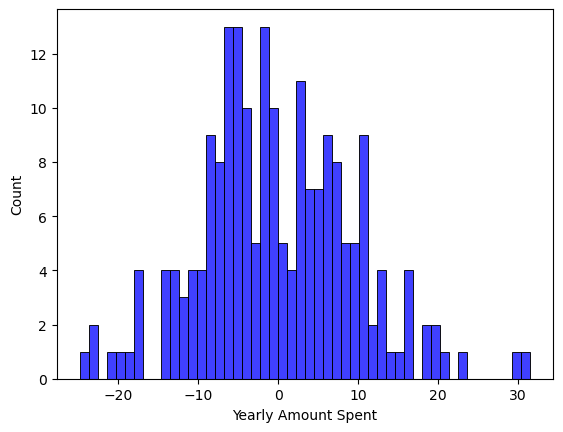

In [21]:
sns.histplot((y_test-predictions),bins=50, color = 'b');
plt.show()

### Loss Functions

In [27]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 7.7426712858387505
MSE: 93.83297800820091
RMSE: 9.686742383701597
